In [4]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from datetime import datetime

sns.set_style("whitegrid")

In [2]:
import os

print("Current Folder:")
print(os.getcwd())

print("\nFiles in Folder:")
print(os.listdir())

Current Folder:
c:\Users\user\Desktop\Crypto Analysis

Files in Folder:
['fear_greed_index.csv', 'historical_data.csv', 'trader_analysis.ipynb']


In [5]:
import pandas as pd

sentiment = pd.read_csv("./fear_greed_index.csv")

sentiment.head()

,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03
3,1517722200,24,Extreme Fear,2018-02-04
4,1517808600,11,Extreme Fear,2018-02-05


In [6]:
trades = pd.read_csv("./historical_data.csv")

trades.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12


In [7]:
print(sentiment.shape)
print(trades.shape)

(2644, 4)
(211224, 16)


In [8]:
print(sentiment.columns)

Index(['timestamp', 'value', 'classification', 'date'], dtype='str')


In [9]:
print(trades.columns)

Index(['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side',
       'Timestamp IST', 'Start Position', 'Direction', 'Closed PnL',
       'Transaction Hash', 'Order ID', 'Crossed', 'Fee', 'Trade ID',
       'Timestamp'],
      dtype='str')


In [11]:
trades['Timestamp IST'] = pd.to_datetime(
    trades['Timestamp IST'],
    dayfirst=True
)

print("Done")

Done


In [12]:
sentiment['Date'] = sentiment['date'].dt.date

trades['Date'] = trades['Timestamp IST'].dt.date

In [13]:
print(sentiment[['date', 'Date']].head())
print(trades[['Timestamp IST', 'Date']].head())

        date        Date
0 2018-02-01  2018-02-01
1 2018-02-02  2018-02-02
2 2018-02-03  2018-02-03
3 2018-02-04  2018-02-04
4 2018-02-05  2018-02-05
        Timestamp IST        Date
0 2024-12-02 22:50:00  2024-12-02
1 2024-12-02 22:50:00  2024-12-02
2 2024-12-02 22:50:00  2024-12-02
3 2024-12-02 22:50:00  2024-12-02
4 2024-12-02 22:50:00  2024-12-02


In [14]:
merged = pd.merge(
    trades,
    sentiment[['Date', 'classification']],
    on='Date',
    how='left'
)

merged.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp,Date,classification
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,2024-12-02 22:50:00,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12,2024-12-02,Extreme Greed
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,2024-12-02 22:50:00,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12,2024-12-02,Extreme Greed
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,2024-12-02 22:50:00,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12,2024-12-02,Extreme Greed
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,2024-12-02 22:50:00,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12,2024-12-02,Extreme Greed
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,2024-12-02 22:50:00,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12,2024-12-02,Extreme Greed


In [15]:
print("Total Trades:", len(merged))

print("Matched Sentiment Records:",
      merged['classification'].notna().sum())

Total Trades: 211224
Matched Sentiment Records: 211218


In [16]:
merged['classification'].value_counts()

classification
Fear             61837
Greed            50303
Extreme Greed    39992
Neutral          37686
Extreme Fear     21400
Name: count, dtype: int64

Total Profit by Sentiment


In [19]:
profit_by_sentiment = merged.groupby('classification')['Closed PnL'].sum()

print(profit_by_sentiment.sort_values(ascending=False))

classification
Fear             3.357155e+06
Extreme Greed    2.715171e+06
Greed            2.150129e+06
Neutral          1.292921e+06
Extreme Fear     7.391102e+05
Name: Closed PnL, dtype: float64


Average Profit per Trade

In [20]:
avg_profit = merged.groupby('classification')['Closed PnL'].mean()

print(avg_profit.sort_values(ascending=False))

classification
Extreme Greed    67.892861
Fear             54.290400
Greed            42.743559
Extreme Fear     34.537862
Neutral          34.307718
Name: Closed PnL, dtype: float64


In [21]:
summary = merged.groupby('classification').agg(
    Trade_Count=('Closed PnL', 'count'),
    Total_PnL=('Closed PnL', 'sum'),
    Avg_PnL=('Closed PnL', 'mean')
)

print(summary.sort_values('Avg_PnL', ascending=False))

                Trade_Count     Total_PnL    Avg_PnL
classification                                      
Extreme Greed         39992  2.715171e+06  67.892861
Fear                  61837  3.357155e+06  54.290400
Greed                 50303  2.150129e+06  42.743559
Extreme Fear          21400  7.391102e+05  34.537862
Neutral               37686  1.292921e+06  34.307718


Win Rate

In [22]:
merged['Win'] = merged['Closed PnL'] > 0

In [23]:
win_rate = merged.groupby('classification')['Win'].mean() * 100

print(win_rate.sort_values(ascending=False))

classification
Extreme Greed    46.494299
Fear             42.076750
Neutral          39.699093
Greed            38.482794
Extreme Fear     37.060748
Name: Win, dtype: float64


Position Size

In [24]:
position_size = merged.groupby('classification')['Size USD'].mean()

print(position_size.sort_values(ascending=False))

classification
Fear             7816.109931
Greed            5736.884375
Extreme Fear     5349.731843
Neutral          4782.732661
Extreme Greed    3112.251565
Name: Size USD, dtype: float64


Buy vs Sell performance.

In [25]:
buy_sell = merged.groupby(
    ['classification', 'Side']
)['Closed PnL'].mean()

print(buy_sell)

classification  Side
Extreme Fear    BUY      34.114627
                SELL     34.980106
Extreme Greed   BUY      10.498927
                SELL    114.584643
Fear            BUY      63.927104
                SELL     45.049641
Greed           BUY      25.002302
                SELL     59.691091
Neutral         BUY      29.227429
                SELL     39.456408
Name: Closed PnL, dtype: float64


Best traders

In [26]:
top_traders = (
    merged.groupby('Account')['Closed PnL']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

print(top_traders)

Account
0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23    2.143383e+06
0x083384f897ee0f19899168e3b1bec365f52a9012    1.600230e+06
0xbaaaf6571ab7d571043ff1e313a9609a10637864    9.401638e+05
0x513b8629fe877bb581bf244e326a047b249c4ff1    8.404226e+05
0xbee1707d6b44d4d52bfe19e41f8a828645437aab    8.360806e+05
0x4acb90e786d897ecffb614dc822eb231b4ffb9f4    6.777471e+05
0x72743ae2822edd658c0c50608fd7c5c501b2afbd    4.293556e+05
0x430f09841d65beb3f27765503d0f850b8bce7713    4.165419e+05
0x72c6a4624e1dffa724e6d00d64ceae698af892a0    4.030115e+05
0x75f7eeb85dc639d5e99c78f95393aa9a5f1170d4    3.790954e+05
Name: Closed PnL, dtype: float64


In [29]:
summary = merged.groupby('classification').agg(
    Trades=('Closed PnL', 'count'),
    Total_PnL=('Closed PnL', 'sum'),
    Avg_PnL=('Closed PnL', 'mean'),
    Avg_Position_Size=('Size USD', 'mean'),
    Win_Rate=('Win', 'mean')
)

summary['Win_Rate'] = summary['Win_Rate'] * 100

summary.round(2)

,Trades,Total_PnL,Avg_PnL,Avg_Position_Size,Win_Rate
classification,,,,,
Extreme Fear,21400,739110.25,34.54,5349.73,37.06
Extreme Greed,39992,2715171.31,67.89,3112.25,46.49
Fear,61837,3357155.44,54.29,7816.11,42.08
Greed,50303,2150129.27,42.74,5736.88,38.48
Neutral,37686,1292920.68,34.31,4782.73,39.70


In [31]:
import matplotlib.pyplot as plt

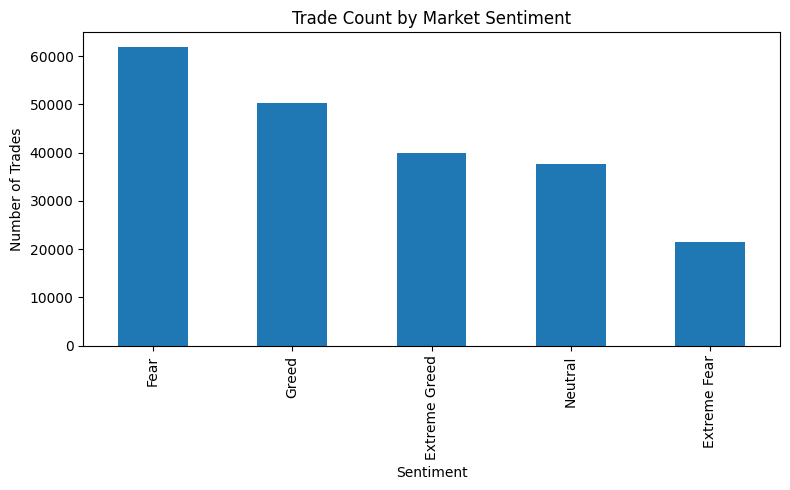

In [32]:
trade_count = merged['classification'].value_counts()

trade_count.plot(
    kind='bar',
    figsize=(8,5),
    title='Trade Count by Market Sentiment'
)

plt.xlabel('Sentiment')
plt.ylabel('Number of Trades')
plt.tight_layout()
plt.show()

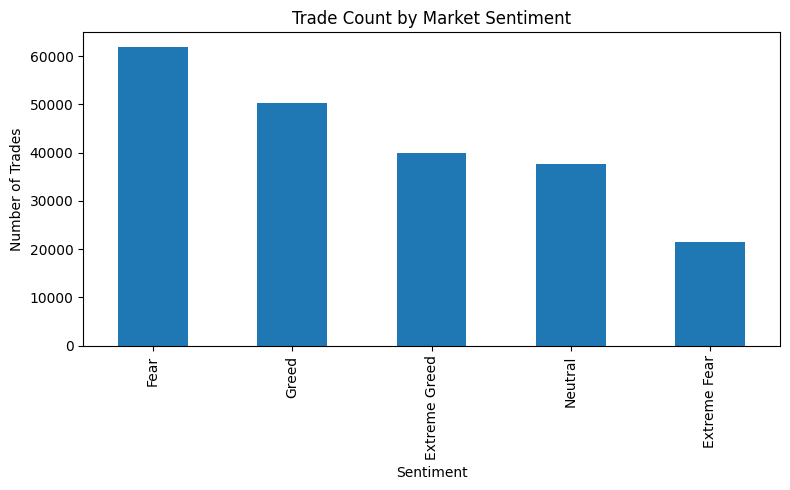

In [33]:
trade_count = merged['classification'].value_counts()

trade_count.plot(
    kind='bar',
    figsize=(8,5),
    title='Trade Count by Market Sentiment'
)

plt.xlabel('Sentiment')
plt.ylabel('Number of Trades')
plt.tight_layout()
plt.show()

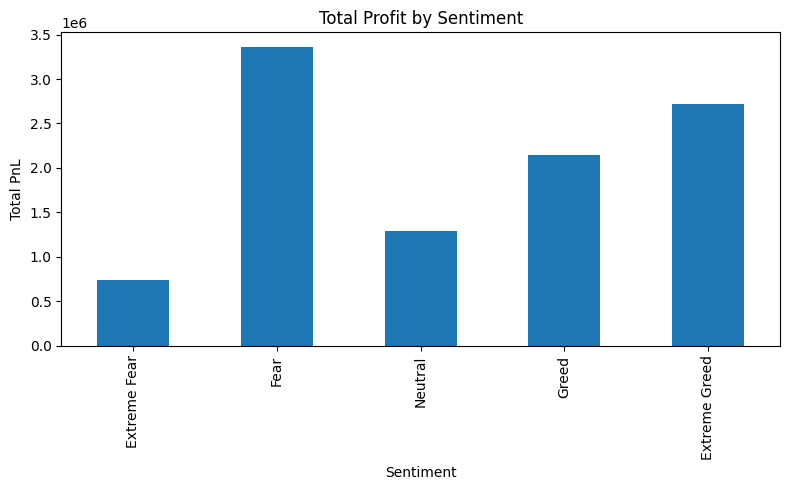

In [35]:
order = [
    'Extreme Fear',
    'Fear',
    'Neutral',
    'Greed',
    'Extreme Greed'
]

profit_by_sentiment = merged.groupby(
    'classification'
)['Closed PnL'].sum().reindex(order)

profit_by_sentiment.plot(
    kind='bar',
    figsize=(8,5),
    title='Total Profit by Sentiment'
)

plt.xlabel('Sentiment')
plt.ylabel('Total PnL')
plt.tight_layout()
plt.show()

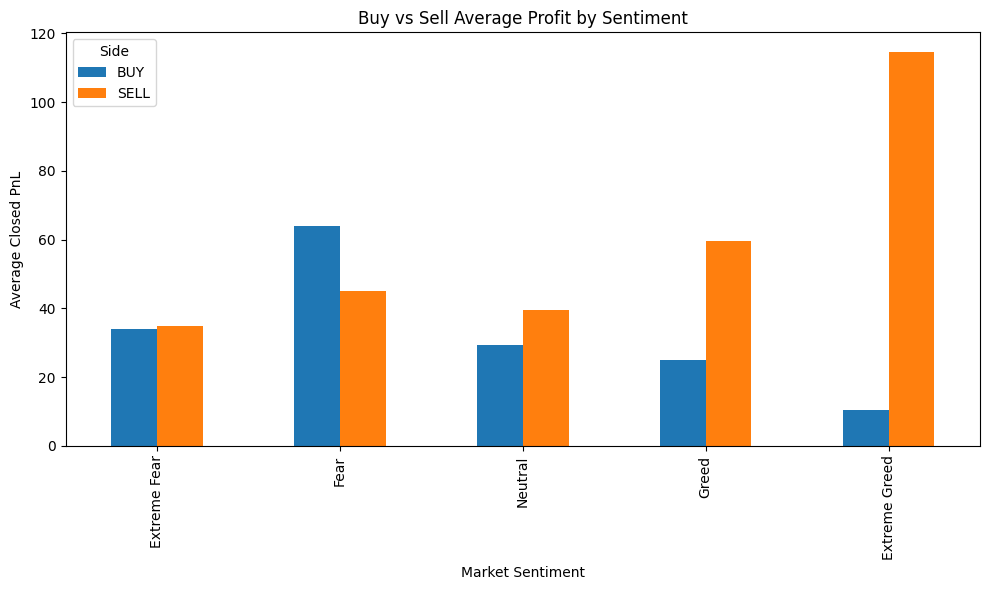

In [36]:
buy_sell = merged.groupby(
    ['classification', 'Side']
)['Closed PnL'].mean().unstack()

buy_sell = buy_sell.reindex([
    'Extreme Fear',
    'Fear',
    'Neutral',
    'Greed',
    'Extreme Greed'
])

buy_sell.plot(
    kind='bar',
    figsize=(10,6)
)

plt.title('Buy vs Sell Average Profit by Sentiment')
plt.xlabel('Market Sentiment')
plt.ylabel('Average Closed PnL')
plt.tight_layout()
plt.show()

In [37]:
summary.to_csv('sentiment_summary.csv')

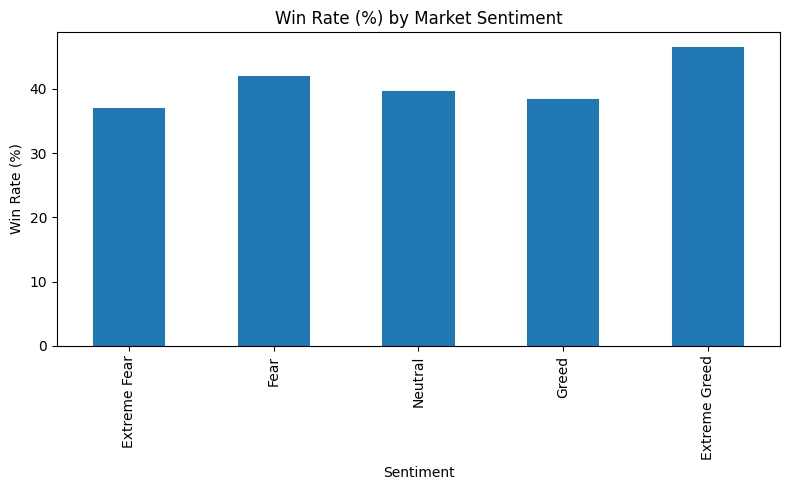

In [38]:
merged['is_win'] = merged['Closed PnL'] > 0
win_rate = merged.groupby('classification')['is_win'].mean() * 100


order = ['Extreme Fear', 'Fear', 'Neutral', 'Greed', 'Extreme Greed']
win_rate = win_rate.reindex(order)

win_rate.plot(
    kind='bar',
    figsize=(8,5),
    title='Win Rate (%) by Market Sentiment'
)

plt.xlabel('Sentiment')
plt.ylabel('Win Rate (%)')
plt.tight_layout()
plt.show()